# Benchmark Analysis: PyPSA vs Antares-Xpansion

Analyze every row of `tmp/xpansion_benchmark_results/xpansion_scenario_results.csv`
(produced by `xpansion_benchmark.py` / the cloud setup script).

Diagrams follow the same simple bar-chart style as `benchmark_analysis.ipynb`.

In [15]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path().resolve().parent.parent
tests_dir = project_root / "tests"
if str(tests_dir) not in sys.path:
    sys.path.insert(0, str(tests_dir))

import utils

importlib.reload(utils)
from utils import analyze_xpansion_benchmark_study, get_xpansion_results_path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 10

In [16]:
results_file = get_xpansion_results_path()
print(f"Results file path: {results_file}")
print(f"File exists: {results_file.exists()}")

if results_file.exists():
    df = pd.read_csv(results_file)
    print(f"\nTotal rows in CSV: {len(df)}")
    print("\nAvailable runs:")
    for idx in range(len(df)):
        row = df.iloc[idx]
        print(
            f"  Row {idx}: {row['study_name']}  "
            f"(scenarios={int(row['n_scenarios'])}, "
            f"buses={int(row['n_buses'])}, "
            f"timesteps={int(row['number_of_time_steps'])}, "
            f"status={row.get('xpansion_status', 'N/A')})"
        )
else:
    print(f"\nError: Results file not found at {results_file}")

Results file path: /home/rtei-beg-see-dp/Gems-Development/PyPSA-to-GEMS-Converter/tmp/xpansion_benchmark_results/xpansion_scenario_results.csv
File exists: True

Total rows in CSV: 8

Available runs:
  Row 0: synthetic_mesh_20x168  (scenarios=2, buses=20, timesteps=168, status=OPTIMAL)
  Row 1: synthetic_mesh_40x168  (scenarios=2, buses=40, timesteps=168, status=OPTIMAL)
  Row 2: synthetic_mesh_40x672  (scenarios=2, buses=40, timesteps=672, status=OPTIMAL)
  Row 3: synthetic_mesh_20x168  (scenarios=10, buses=20, timesteps=168, status=OPTIMAL)
  Row 4: synthetic_mesh_40x168  (scenarios=10, buses=40, timesteps=168, status=OPTIMAL)
  Row 5: synthetic_mesh_40x672  (scenarios=10, buses=40, timesteps=672, status=OPTIMAL)
  Row 6: synthetic_mesh_20x168  (scenarios=50, buses=20, timesteps=168, status=OPTIMAL)
  Row 7: synthetic_mesh_40x168  (scenarios=50, buses=40, timesteps=168, status=OPTIMAL)


## Analyze all runs

Loop over every row in the CSV and plot the comparison charts.

XPANSION BENCHMARK ANALYSIS - ROW 0

NETWORK INFORMATION:
  Study: synthetic_mesh_20x168
  Buses: 20
  Time steps: 168
  Scenarios: 2
  Antares Xpansion: v1.9.0
  GemsPy: 0.1.3

TIMING:
  Xpansion status: OPTIMAL
  Xpansion total: 1.9310 s
  PyPSA build: 0.6597 s
  PyPSA solve: 0.7037 s
  PyPSA total: 1.3634 s
  Speedup (PyPSA / Xpansion): 0.71x (PyPSA faster)

OBJECTIVE:
  Xpansion: 1.219274e+07
  PyPSA:    1.220263e+07
  Rel. gap: 0.08 %

PYPSA MODEL SIZE:
  Constraints: 34,016
  Variables:   13,462



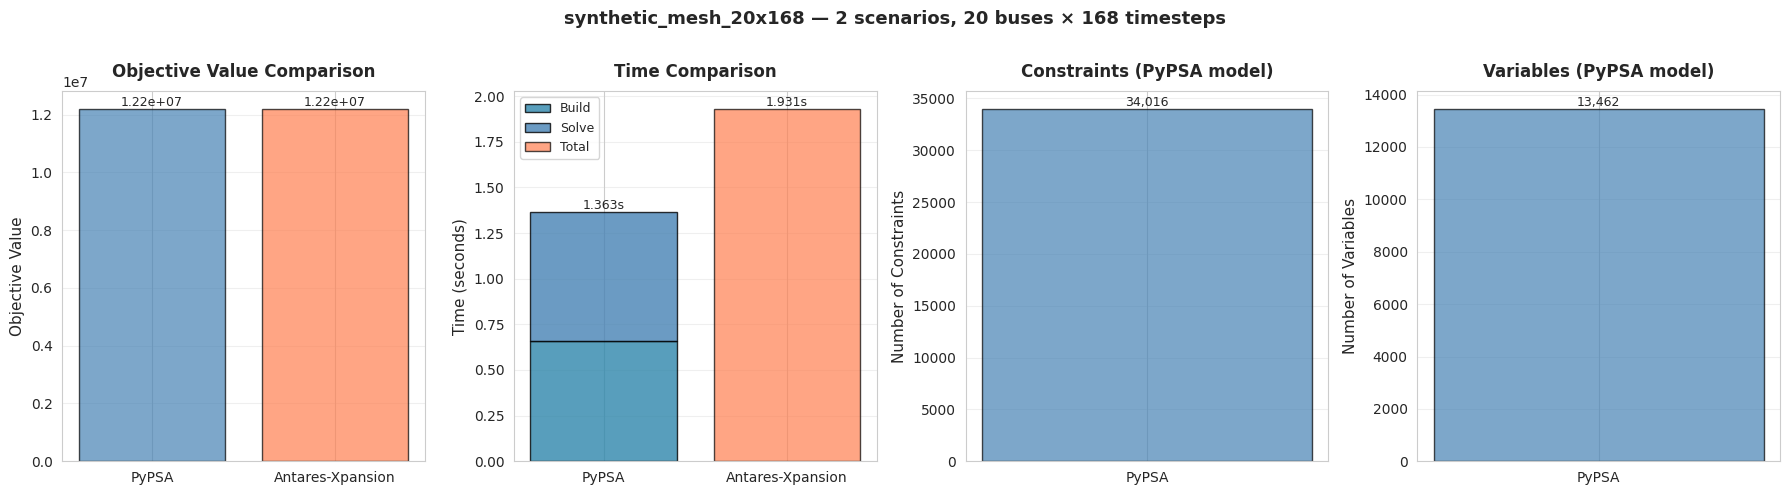

,study_name,n_buses,n_scenarios,antares_xpansion_version,gemspy_version,pypsa_network_name,number_of_time_steps,network_build_time,pypsa_to_gems_conversion_time,xpansion_total_time,xpansion_status,xpansion_objective_value,pypsa_build_time,pypsa_solve_time,pypsa_total_time,number_of_constraints_pypsa,number_of_variables_pypsa,pypsa_objective,pypsa_solver_name
0,synthetic_mesh_20x168,20.0,2.0,v1.9.0,0.1.3,synthetic_mesh_20x168,168.0,0.504789,0.499319,1.930964,OPTIMAL,1.219274e+07,0.65966,0.703729,1.363389,34016.0,13462.0,1.220263e+07,cbc


In [17]:
results_file = get_xpansion_results_path()
df = pd.read_csv(results_file)

for row_number in range(len(df)):
    analyze_xpansion_benchmark_study(row_number)

XPANSION BENCHMARK ANALYSIS - ROW 6

NETWORK INFORMATION:
  Study: synthetic_mesh_20x168
  Buses: 20
  Time steps: 168
  Scenarios: 50
  Antares Xpansion: v1.9.0
  GemsPy: 0.1.3

TIMING:
  Xpansion status: OPTIMAL
  Xpansion total: 1.6018 s
  PyPSA build: 1.2287 s
  PyPSA solve: 158.4142 s
  PyPSA total: 159.6428 s
  Speedup (PyPSA / Xpansion): 99.67x (Xpansion faster)

OBJECTIVE:
  Xpansion: 1.193142e+07
  PyPSA:    1.256254e+07
  Rel. gap: 5.02 %

PYPSA MODEL SIZE:
  Constraints: 850,400
  Variables:   336,070



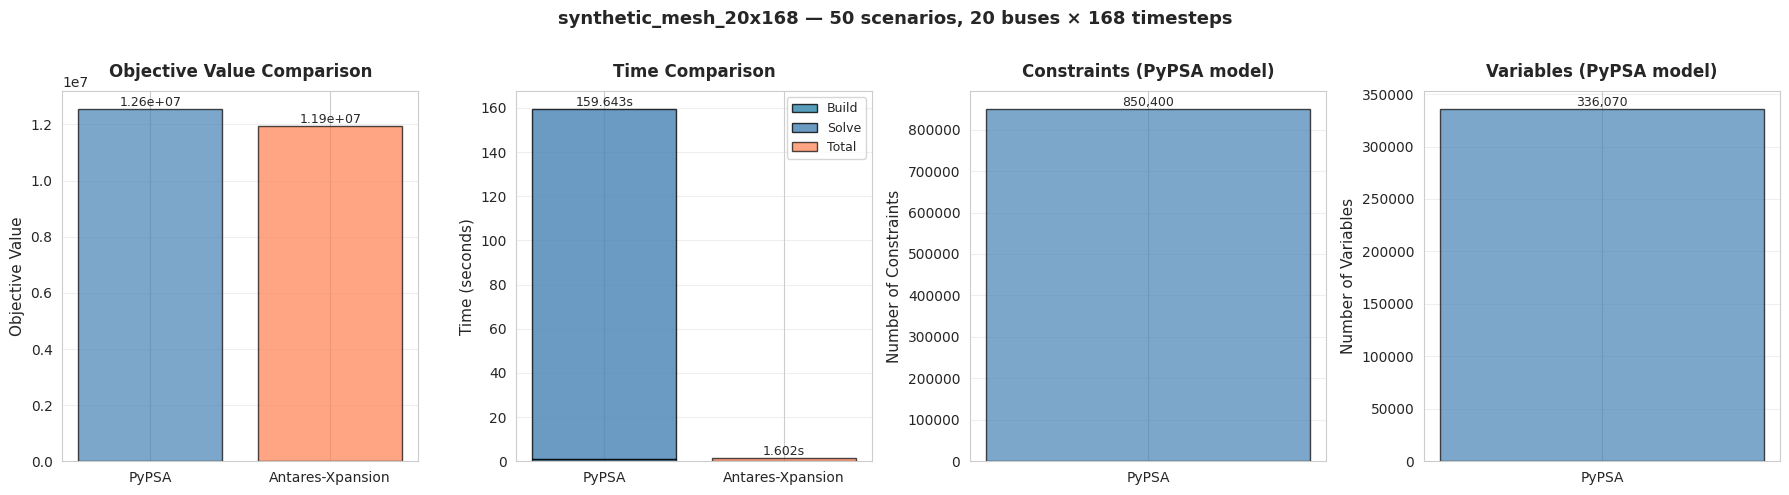

,study_name,n_buses,n_scenarios,antares_xpansion_version,gemspy_version,pypsa_network_name,number_of_time_steps,network_build_time,pypsa_to_gems_conversion_time,xpansion_total_time,xpansion_status,xpansion_objective_value,pypsa_build_time,pypsa_solve_time,pypsa_total_time,number_of_constraints_pypsa,number_of_variables_pypsa,pypsa_objective,pypsa_solver_name
6,synthetic_mesh_20x168,20.0,50.0,v1.9.0,0.1.3,synthetic_mesh_20x168,168.0,0.693177,0.924105,1.601752,OPTIMAL,1.193142e+07,1.228666,158.41417,159.642836,850400.0,336070.0,1.256254e+07,cbc


In [18]:
# Optional: analyze a single row
# analyze_xpansion_benchmark_study(3)
